# Electrical stimulation fMRI pipeline: stitching, preprocessing and analysis

1. Convert the raw Bruker functional scans (same session and subject, acquired back-to-back with identical acquisition parameters) to NIfTI and concatenate them in the given order.
2. Motion-correct the stitched series once against a single reference volume (the middle volume of the whole series).
3. Mask, spatially smooth, compute the signal change map, coregister to the structural scan and run the stimulation check on every region of the atlas (no manual ROIs).

Enter the functional scan numbers in acquisition order. `scan_boundaries.csv` in the functional analysis folder records the volume range of each original scan.

In [2]:
import pandas as pd
import numpy as np
from nipype.interfaces import afni, fsl
import nibabel as nib
import matplotlib.pyplot as plt
import os, datetime
import csv
import shutil
import glob
import subprocess
from pathlib import Path
import re
import getpass
import ipywidgets as widgets
from IPython.display import display
from ipyfilechooser import FileChooser
from tabulate import tabulate

#Prime functions, can be choosen to run in the next cell
def smooth_movavg(in_file, out_file, win_sec_duration, tr):

  win = max(1, int(round(win_sec_duration / tr)))
  
  # Apply moving average
  def moving_average_1d(x, win):
      k = np.ones(win, dtype=float) / win
      xpad = np.pad(x, (win//2, win-1-win//2), mode='edge')  # reduce edge shrinkage
      return np.convolve(xpad, k, mode='valid')

  img = nib.load(in_file)
  data = img.get_fdata()   # X,Y,Z,T
  T = data.shape[-1]
  flat = data.reshape(-1, T)
  sm = np.vstack([moving_average_1d(ts, win) for ts in flat]).reshape(data.shape)

  nib.Nifti1Image(sm, img.affine, img.header).to_filename(out_file)
  print(f"Wrote: {out_file}  (tr={tr}s, window={win_sec_duration}s => {win} vols)")

def bruker_to_nifti(in_path, scan_number, out_file):

    scan_dir = os.path.join(in_path, scan_number)
    method_file = os.path.join(scan_dir, "method")

    # -------------------------------------------------------
    # Helper: safely collect only produced NIfTI files
    # -------------------------------------------------------
    def get_nifti_files(scan_number):
        return [
            f for f in glob.glob(f"*{scan_number}*.nii*")
            if os.path.isfile(f)
        ]

    # ---------- 1) Run brkraw tonii ----------
    cmd = ["brkraw", "tonii", f"{in_path}/", "-s", str(scan_number)]
    subprocess.run(cmd, check=True)

    # ---------- 2) Detect echo count ----------
    NoOfEchoImages = None
    if os.path.exists(method_file):
        with open(method_file) as f:
            for line in f:
                if "PVM_NEchoImages=" in line:
                    echo_str = line.split("=")[1].strip()
                    try:
                        NoOfEchoImages = int(echo_str)
                    except:
                        NoOfEchoImages = 1
                    break

    # ---------- 3) Collect produced NIfTI files ----------
    src_files = get_nifti_files(scan_number)

    if not src_files:
        raise RuntimeError(
            f"No NIfTI files found after brkraw conversion for scan {scan_number}"
        )

    # ---------- 4) Single echo OR unknown echo ----------
    if NoOfEchoImages is None or NoOfEchoImages == 1:
        # Just copy first detected nifti
        shutil.copy(src_files[0], "G1_cp.nii.gz")

    # ---------- 5) Multi-echo ----------
    else:
        merged_file = f"{scan_number}_combined_images.nii.gz"

        # Merge all echoes
        subprocess.run(
            ["fslmerge", "-t", merged_file] + src_files,
            check=True
        )

        shutil.copy(merged_file, "G1_cp.nii.gz")

    # ---------- 6) Fix orientation to LPI ----------
    print(f"{bcolors.NOTIFICATION}Fixing orientation to LPI{bcolors.ENDC}")

    resample = afni.Resample()
    resample.inputs.in_file = "G1_cp.nii.gz"
    resample.inputs.out_file = out_file
    resample.inputs.orientation = "LPI"
    resample.run()

    # ---------- 7) Save NIfTI header info ----------
    with open("NIFTI_file_header_info.txt", "w") as out:
        subprocess.run(["fslhd", out_file], stdout=out, check=True)

    print_statement(
        f"[OK] Bruker → NIFTI workflow completed.",
        bcolors.OKGREEN
    )
def extract_middle_volume(in_file, reference_vol, out_file, size):
  extract_vol = fsl.ExtractROI()
  extract_vol.inputs.in_file=in_file 
  extract_vol.inputs.t_min=reference_vol 
  extract_vol.inputs.t_size=size 
  extract_vol.inputs.roi_file=out_file
  extract_vol.run()

  print("[OK] Intended Volumes extracted.")
  return out_file
def motion_correction(reference_vol, input_vol, output_prefix):

    # ---------- 1) 3dvolreg ----------
    
    volreg = afni.Volreg()  
    volreg.inputs.in_file = input_vol
    volreg.inputs.basefile = reference_vol
    volreg.inputs.out_file = f"{output_prefix}.nii.gz"
    volreg.inputs.oned_file = "motion.1D"
    volreg.inputs.args = '-linear'
    volreg.inputs.oned_matrix_save = "rmsabs.1D"
    volreg.inputs.verbose = True
    volreg.run()

    print("[INFO] Running 3dvolreg…")
    return output_prefix
def plot_motion_parameters(input_file):

    # ---------- 4) Plot motion parameters ----------
    print("[INFO] Creating motion plots…")

    # Translation plots
    data = np.loadtxt(input_file)

    # X-axis (row index / timepoints)
    x = np.arange(data.shape[0])

    # -------- Plot 1: first 3 columns --------
    plt.figure(figsize=(8, 4))
    for i in range(3):
        plt.plot(x, data[:, i], label=f"Column {i+1}")

    plt.title("Rotation")
    plt.xlabel("Volume Number")
    plt.ylabel("Rotation in degrees")
    plt.legend(["Pitch (x)", "Roll (y)", "Yaw (z)"])
    plt.tight_layout()
    plt.savefig("motion_rotations.svg", dpi=1200)
    # -------- Plot 2: next 3 columns --------
    plt.figure(figsize=(8, 4))
    for i in range(3, 6):
        plt.plot(x, data[:, i], label=f"Column {i+1}")

    plt.title("Translation")
    plt.xlabel("Volume Number")
    plt.ylabel("Translation in mm")
    plt.legend(["Read (x)", "Phase (y)", "Slice (z)"])
    plt.tight_layout()
    plt.savefig("motion_translations.svg", dpi=1200)
def compute_mean_range(input_file, prefix, start_idx, end_idx):
    
    afni_cmd = ["3dTstat", "-mean", "-prefix", prefix, f"{input_file}[{start_idx}..{end_idx}]"]

    print("[INFO] Running:", " ".join(afni_cmd))

    subprocess.run(afni_cmd, check=True)
    print_statement("[OK] Mean baseline image saved.", bcolors.OKGREEN)
def masking_file(input_file, mask_file, output_file):
    
    math = fsl.maths.ApplyMask()
    math.inputs.in_file = input_file
    math.inputs.mask_file = mask_file
    math.inputs.out_file = output_file

    math.run()

    print_statement(f"[OK] Masked file saved → {output_file}", bcolors.OKGREEN)
    return output_file
def tSNR(input_file, output_file, reference_vol, size):
  
  extract_middle_volume(input_file, reference_vol, "extracted_ts.nii.gz", size)

  mean = fsl.maths.MeanImage()
  mean.inputs.in_file = "extracted_ts.nii.gz"
  mean.inputs.out_file = "mean_image.nii.gz"
  mean.run()

  std = fsl.maths.StdImage()
  std.inputs.in_file = "extracted_ts.nii.gz"
  std.inputs.out_file = "std_image.nii.gz"
  std.run()

  tSNR = fsl.maths.BinaryMaths()
  tSNR.inputs.in_file = "mean_image.nii.gz"
  tSNR.inputs.operand_file = "std_image.nii.gz"
  tSNR.inputs.operation = "div"
  tSNR.inputs.out_file = output_file
  tSNR.run()

  print_statement(f"[OK] tSNR file saved → {output_file}", bcolors.OKGREEN)
  return output_file
def spatial_smoothing(input_file, output_file, fwhm):
    cmd = ["fslmaths", input_file, "-kernel", "gauss", str(fwhm), "-fmean", output_file]

    subprocess.run(cmd, check=True)
    print("Smoothing completed successfully.")
def signal_change_map(signal_file, baseline_file, output_file):
   
  tmp_sub = "tmp_signal_minus_baseline.nii.gz"
  tmp_div = "tmp_psc_raw.nii.gz"

  sub = fsl.BinaryMaths()
  sub.inputs.in_file = signal_file
  sub.inputs.operand_file = baseline_file
  sub.inputs.operation = "sub"
  sub.inputs.out_file = tmp_sub
  sub.run()

  div = fsl.BinaryMaths()
  div.inputs.in_file = tmp_sub
  div.inputs.operand_file = baseline_file
  div.inputs.operation = "div"
  div.inputs.out_file = tmp_div
  div.run()

  mul = fsl.BinaryMaths()
  mul.inputs.in_file = tmp_div
  mul.inputs.operation = "mul"
  mul.inputs.operand_value = 100
  mul.inputs.out_file = output_file
  mul.run()

  os.remove(tmp_sub)
  os.remove(tmp_div)

  print_statement(f"[OK] Percent Signal Change Map saved → {output_file}", bcolors.OKGREEN)
  return output_file
def coregistration_afni_old(input_file1=None, 
                        input_file2=None, 
                        reference_file=None, 
                        output_file1=None, 
                        output_file2=None, 
                        estimate_affine=True, 
                        apply_affine=True, 
                        affine_mat="mean_func_struct_aligned.aff12.1D"):

  results = {}

  # -------- STEP 1: Estimate affine --------
  if estimate_affine:
      if output_file1 is None:
          raise ValueError("output_file1 must be provided when estimate_affine=True")
      if input_file1 is None:
          raise ValueError("input_file1 must be provided when estimate_affine=True")

      coreg_wo_affine = afni.Allineate()
      coreg_wo_affine.inputs.in_file = input_file1
      coreg_wo_affine.inputs.reference = reference_file
      coreg_wo_affine.inputs.out_matrix = affine_mat
      coreg_wo_affine.inputs.cost = "crU"
      coreg_wo_affine.inputs.two_pass = True
      coreg_wo_affine.inputs.verbose = True
      coreg_wo_affine.inputs.out_file = output_file1
      coreg_wo_affine.inputs.out_param_file = "params.1D"
      coreg_wo_affine.run()

      print(f"[OK] Affine estimated and saved → {affine_mat}")
      print(f"[OK] Coregistered image (step 1) → {output_file1}")

      results["step1"] = output_file1

  # -------- STEP 2: Apply affine --------
  if apply_affine:
      if output_file2 is None:
          raise ValueError("output_file2 must be provided when apply_affine=True")
      if input_file2 is None:
          raise ValueError("input_file2 must be provided when apply_affine=True")


      coreg_with_affine = afni.Allineate()
      coreg_with_affine.inputs.in_file = input_file2
      coreg_with_affine.inputs.reference = reference_file
      coreg_with_affine.inputs.in_matrix = affine_mat
      coreg_with_affine.inputs.master = reference_file
      coreg_with_affine.inputs.verbose = True
      coreg_with_affine.inputs.final_interpolation = "linear"
      coreg_with_affine.inputs.out_file = output_file2
      coreg_with_affine.run()

      print_statement(f"[OK] Affine applied → {output_file2}", bcolors.OKGREEN)
      results["step2"] = output_file2

  return results

def run_cmd(cmd):
    """Run shell command and return stdout."""
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
    return result.stdout.strip()
def create_intensity_mask(input_img, output_mask, low_percentile, high_percentile):
    """
    Create binary mask keeping voxels between given percentiles.

    Parameters
    ----------
    input_img : str
        Path to 3D NIfTI image
    output_mask : str
        Output mask filename
    low_percentile : float
        Lower percentile (e.g., 20)
    high_percentile : float
        Upper percentile (e.g., 80)
    """

    # -------------------------
    # Validate percentiles
    # -------------------------
    if not (0 <= low_percentile < high_percentile <= 100):
        raise ValueError("Percentiles must satisfy: 0 <= low < high <= 100")

    # Get percentile thresholds
    p_low = float(run_cmd(["fslstats", input_img, "-l", "0.0001", "-P", str(low_percentile)]))
    p_high = float(run_cmd(["fslstats", input_img, "-l", "0.0001", "-P", str(high_percentile)]))


    # Create binary mask
    subprocess.run(["fslmaths", input_img, "-thr", str(p_low), "-uthr", str(p_high), "-bin", output_mask], check=True)

    print(f"Mask created: {output_mask}")
    print(f"Thresholds used: {p_low:.3f} – {p_high:.3f}")
def make_3x3_roi_same_slice(ref_nii_path, center_phase, center_slice, center_read, out_path):
    """
    Creates a 3x3 ROI (9 voxels) centered at (phase, slice, read),
    keeping slice fixed, expanding +/-1 in phase and read.

    Axis convention: data[phase, slice, read]
    """
    ref_img = nib.load(ref_nii_path)
    shape = ref_img.shape

    roi = np.zeros(shape, dtype=np.uint8)

    p0, s0, r0 = int(center_phase), int(center_slice), int(center_read)

    # Clip to bounds (if center is near edges, ROI may contain < 9 voxels)
    p1 = max(p0 - 1, 0)
    p2 = min(p0 + 1, shape[0] - 1)
    r1 = max(r0 - 1, 0)
    r2 = min(r0 + 1, shape[2] - 1)

    if not (0 <= s0 < shape[1]):
        raise ValueError(f"center_slice {s0} out of bounds for shape {shape}")

    roi[p1:p2+1, s0, r1:r2+1] = 1

    out_img = nib.Nifti1Image(roi, ref_img.affine, header=ref_img.header.copy())
    out_img.set_data_dtype(np.uint8)
    nib.save(out_img, out_path)

    return out_path
def save_roi_from_max(scm_path, hemisphere_mask_path, res):
    # Decide output name from hemisphere mask filename
    mask_name = os.path.basename(hemisphere_mask_path).lower()
    out_name = "roi_left.nii.gz" if "left" in mask_name else "roi_right.nii.gz"

    out_path = os.path.join(os.path.dirname(hemisphere_mask_path), out_name)

    make_3x3_roi_same_slice(ref_nii_path=scm_path, center_phase=res["phase"], center_slice=res["slice"], center_read=res["read"], out_path=out_path)
    return out_path
def max_voxel_in_mask(scm_path, mask_path, slice_pick=None, slice_pad=1):
    """
    
    Finds the voxel with highest SCM intensity inside a binary mask.

    Axis convention assumed (same as your code):
      scm_data[phase, slice, read]

    slice_pick:
      - None -> search all slices in the mask
      - int  -> search only slice_pick ± slice_pad
    """
    scm_img  = nib.load(scm_path)
    scm_data = scm_img.get_fdata()

    mask = nib.load(mask_path).get_fdata() > 0

    if mask.shape != scm_data.shape:
        raise ValueError(f"Mask shape {mask.shape} != SCM shape {scm_data.shape}")

    # Optional: restrict to user-chosen slice ± pad
    if slice_pick is not None:
        sp = int(slice_pick)
        pad = int(slice_pad)

        coords = np.argwhere(mask)  # (phase, slice, read)
        keep = (coords[:, 1] >= sp - pad) & (coords[:, 1] <= sp + pad)

        coords = coords[keep]
        if coords.size == 0:
            return None

        vals = scm_data[coords[:, 0], coords[:, 1], coords[:, 2]]
        idx  = int(np.nanargmax(vals))
        phase, slice_, read = coords[idx]
        value = float(vals[idx])

    else:
        coords = np.argwhere(mask)          # (phase, slice, read)
        vals   = scm_data[mask]
        idx    = int(np.nanargmax(vals))
        phase, slice_, read = coords[idx]
        value  = float(vals[idx])

    return {"read": int(read), "phase": int(phase), "slice": int(slice_), "value": value}


# Helper functions, compulsory to run
def time_course_extraction(roi_file, func_file, output_file):
   
    ts = fsl.ImageMeants()
    ts.inputs.in_file = func_file
    ts.inputs.mask = roi_file
    ts.inputs.out_file = output_file

    ts.run()
def func_param_extract(scan_dir, export_env=True):

    scan_dir = Path(scan_dir)
    acqp_file = scan_dir / "acqp"
    method_file = scan_dir / "method"
    

    if not acqp_file.exists() or not method_file.exists():
        raise FileNotFoundError("acqp or method file not found")

    # -----------------------------
    # Read files
    # -----------------------------
    acqp_text = acqp_file.read_text()
    method_text = method_file.read_text()

    # -----------------------------
    # Sequence name (ACQ_protocol_name)
    # -----------------------------
    seq_match = re.search(
        r"ACQ_protocol_name=\(\s*64\s*\)\s*\n\s*<([^>]+)>",
        acqp_text
    )
    SequenceName = seq_match.group(1) if seq_match else None

    # -----------------------------
    # Extract numeric parameters
    # -----------------------------
    def get_value(pattern, text, cast=int):
        m = re.search(pattern, text)
        return cast(m.group(1)) if m else None

    NoOfRepetitions = get_value(r"##\$PVM_NRepetitions=\s*(\d+)", method_text)
    TotalScanTime = get_value(r"##\$PVM_ScanTime=\s*(\d+)", method_text)

    Baseline_TRs = get_value(r"PreBaselineNum=\s*(\d+)", method_text)
    StimOn_TRs = get_value(r"StimNum=\s*(\d+)", method_text)
    StimOff_TRs = get_value(r"InterStimNum=\s*(\d+)", method_text)
    NoOfEpochs = get_value(r"NEpochs=\s*(\d+)", method_text)

    # -----------------------------
    # Derived values
    # -----------------------------
    VolTR_msec = None
    VolTR = None
    MiddleVolume = None

    if NoOfRepetitions and TotalScanTime:
        VolTR_msec = TotalScanTime / NoOfRepetitions
        VolTR = VolTR_msec / 1000
        MiddleVolume = NoOfRepetitions / 2

    # -----------------------------
    # Pack results
    # -----------------------------
    params = {
        "SequenceName": SequenceName,
        "NoOfRepetitions": NoOfRepetitions,
        "TotalScanTime": TotalScanTime,
        "VolTR_msec": VolTR_msec,
        "VolTR": VolTR,
        "Baseline_TRs": Baseline_TRs,
        "StimOn_TRs": StimOn_TRs,
        "StimOff_TRs": StimOff_TRs,
        "NoOfEpochs": NoOfEpochs,
        "MiddleVolume": MiddleVolume,
    }

    # -----------------------------
    # Export to environment (optional)
    # -----------------------------
    if export_env:
        for k, v in params.items():
            if v is not None:
                os.environ[k] = str(v)

    return params
def extract_subject_id(scan_dir):
    subject_file = Path(scan_dir) / "subject"

    if not subject_file.exists():
        raise FileNotFoundError(f"'subject' file not found in {scan_dir}")

    with subject_file.open("r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if line.strip().startswith("##$SUBJECT_id"):
            # The value is expected on the next line
            value_line = lines[i + 1].strip()
            return value_line.strip("<>")

    raise ValueError("##$SUBJECT_id not found in subject file")
def print_header(message, color):
    line = "*" * 134   # same width everywhere
    width = len(line)

    print()
    print(f"{color}{line}{bcolors.ENDC}")
    print(f"{color}{message.center(width)}{bcolors.ENDC}")
    print(f"{color}{line}{bcolors.ENDC}")
    print()
def print_statement(message, color):
    print(f"{color}{message}{bcolors.ENDC}")
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    NOTIFICATION = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
def view_images(input_image, cmap="gray"):
    img = nib.load(input_image)
    data = img.get_fdata()

    # Handle 4D vs 3D safely
    if data.ndim == 4:
        data = data[..., 0]   # take first volume
    elif data.ndim != 3:
        raise ValueError(f"Unsupported data shape: {data.shape}")

    ny = data.shape[1]
    cols = 8
    rows = int(np.ceil(ny / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes):
        if i < ny:
            ax.imshow(data[:, i, :].T, cmap=cmap, origin="lower")
            ax.set_title(f"y={i}", fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
def matching_nifti_files(directory, ref_shape):
    matches = []

    ref_xyz = tuple(ref_shape[:3])  # (64,16,64)
    print(f"Reference spatial shape: {ref_xyz}")

    for f in sorted(os.listdir(directory)):
        if f.endswith((".nii", ".nii.gz")):
            try:
                img = nib.load(os.path.join(directory, f))
                img_xyz = tuple(img.shape[:3])

                if img_xyz == ref_xyz:
                    matches.append(f)

            except Exception as e:
                print(f"Skipping {f}: {e}")

    
    return matches
def roi_analysis(func_in_file, roi_file, n_vols, tr, base_start, base_end, sig_start, sig_end):
    print_statement(f"Extracting time course for ROI: {roi_file}", bcolors.NOTIFICATION)
    output_file = f"time_course_{roi_file.replace('.nii.gz', '.txt')}"
    time_course_extraction(roi_file, func_in_file, output_file)
    print_statement(f"[OK] Time course saved → {output_file}", bcolors.OKGREEN)

    #Creating Percent Signal Change graphs for each ROI
    id_arr = np.arange(n_vols)
    time_series = np.loadtxt(output_file)
    baseline = np.mean(time_series[base_start:base_end])
    psc = ((time_series - baseline) / baseline) * 100
    mean_signal = np.mean(psc[sig_start:sig_end])
    print_statement(f"[OK] Percent Signal Change calculated for ROI: {roi_file}", bcolors.OKGREEN)
    print("Time Series is:", psc)
    np.savetxt(f"PSC_time_series_{roi_file.replace('.nii.gz', '.txt')}", psc)
    plt.figure(figsize=(10, 5))
    plt.plot(id_arr, psc, label='Percent Signal Change')
    plt.axvspan(base_start, base_end, color='green', alpha=0.3, label='Baseline Period')
    plt.axvspan(sig_start, sig_end, color='blue', alpha=0.3, label='Signal Period')
    plt.title(f'Percent Signal Change Time Series for {roi_file}')
    plt.xlabel('Time Points (Volumes)')
    plt.ylabel('MRI Signal Change (%)')
    plt.set_ylim = (-2, 10)
    plt.legend()
    plt.tight_layout()
    graph_file = f"PSC_Time_Series_{roi_file.replace('.nii.gz', '.svg')}"
    plt.savefig(graph_file, dpi=1200)
    print_statement(f"[OK] Percent Signal Change graph saved → {graph_file}", bcolors.OKGREEN)   

    return mean_signal
def int_widget(value, desc):
    return widgets.IntText(
        value=value,
        description=desc,
        layout=INPUT_LAYOUT,
        style={'description_width': DESC_WIDTH}
    )
def print_selected_pipeline_steps():
    print("\nPIPELINE STEP SELECTION SUMMARY")
    print("-" * 40)

    for step in PIPELINE_STEPS:
        key = step["key"]
        name = step["name"]

        if checkboxes[key].value:
            print(f"[✓] {name}")
        else:
            print(f"[ ] {name}")

    print("-" * 40)
def shrink_mask_xz_linewise(in_mask, out_mask, trim_x=3, trim_z=3):
    img = nib.load(in_mask)
    data = img.get_fdata()

    if data.ndim != 3:
        raise ValueError("Input mask must be 3D")

    X, Y, Z = data.shape
    mask = data.copy()

    # Temporary mask after X-shrink
    tmp_mask = np.zeros_like(mask, dtype=mask.dtype)
    final_mask = np.zeros_like(mask, dtype=mask.dtype)

    # ==========================================================
    # STEP 1 — Shrink along X for every (Y, Z)
    # ==========================================================
    for y in range(Y):
        for z in range(Z):
            line = mask[:, y, z]
            idx = np.where(line > 0)[0]

            if idx.size < 2 * trim_x + 1:
                continue

            x_min = idx.min() + trim_x
            x_max = idx.max() - trim_x

            tmp_mask[x_min:x_max + 1, y, z] = mask[x_min:x_max + 1, y, z]

    # ==========================================================
    # STEP 2 — Shrink along Z for every (Y, X)
    # ==========================================================
    for y in range(Y):
        for x in range(X):
            line = tmp_mask[x, y, :]
            idx = np.where(line > 0)[0]

            if idx.size < 2 * trim_z + 1:
                continue

            z_min = idx.min() + trim_z
            z_max = idx.max() - trim_z

            final_mask[x, y, z_min:z_max + 1] = \
                tmp_mask[x, y, z_min:z_max + 1]

    nib.save(
        nib.Nifti1Image(final_mask, img.affine, img.header),
        out_mask
    )

    print(f"[OK] Line-wise shrunk mask saved → {out_mask}")
def sanitize(value, na_text="NA"):
    """
    Convert undefined / empty values to 'NA'
    """
    if value is None:
        return na_text
    if isinstance(value, str) and value.strip() == "":
        return na_text
    return value
def safe_get(varname):
    """
    Safely get a variable that may not exist.
    """
    return locals().get(varname, globals().get(varname, None))
def validate_analysis_inputs(fields):
    """
    Logical validation only.
    Missing values are allowed and stored as NA.
    """

    if fields["temporal_res"] not in (None, "NA"):
        if fields["temporal_res"] <= 0:
            raise RuntimeError("Invalid temporal resolution (TR must be > 0)")

    if fields["window_duration"] not in (None, "NA"):
        if fields["window_duration"] <= 0:
            raise RuntimeError("Invalid window duration")

    if (
        fields["start_idx_correlation"] not in (None, "NA")
        and fields["end_idx_correlation"] not in (None, "NA")
    ):
        if fields["start_idx_correlation"] >= fields["end_idx_correlation"]:
            raise RuntimeError("Invalid correlation window indices")
def is_step_enabled(step_key):
    return checkboxes.get(step_key, None) and checkboxes[step_key].value


In [3]:
# Copying freshly written files within the SMB share on macOS can yield a truncated 4096-byte copy; force client-side copies
if hasattr(shutil, "_HAS_FCOPYFILE"):
    shutil._HAS_FCOPYFILE = False


# Stitching helpers
def n_volumes(nifti_file):
    out = subprocess.run(
        ["fslnvols", str(nifti_file)],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True
    )
    return int(out.stdout.strip())


def write_boundaries_csv(scan_files, per_scan_volumes, out_csv):
    boundaries = []
    start = 0
    for idx, (scan_file, n_vols) in enumerate(zip(scan_files, per_scan_volumes), start=1):
        end = start + n_vols - 1
        boundaries.append({"scan": idx, "source_file": scan_file,
                            "start_volume": start, "end_volume": end, "n_volumes": n_vols})
        start = end + 1

    with open(out_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["scan", "source_file", "start_volume", "end_volume", "n_volumes"])
        writer.writeheader()
        writer.writerows(boundaries)

    print_header("Scan boundaries in stitched series (0-based, inclusive)", bcolors.HEADER)
    for b in boundaries:
        print_statement(
            f"Scan {b['scan']}: volumes {b['start_volume']}-{b['end_volume']} "
            f"({b['n_volumes']} vols) <- {b['source_file']}",
            bcolors.OKBLUE,
        )
    return boundaries


def is_bruker_raw_scan_dir(path):
    p = Path(path)
    return p.is_dir() and (p / "method").is_file()


def bruker_scan_to_nifti(in_path, scan_number, work_dir, out_name):
    """Same steps as bruker_to_nifti(), but isolated in work_dir so several scans don't collide."""
    in_path = Path(in_path)
    scan_number = str(scan_number)
    work_dir = Path(work_dir)
    work_dir.mkdir(parents=True, exist_ok=True)

    scan_dir = in_path / scan_number
    method_file = scan_dir / "method"
    if not is_bruker_raw_scan_dir(scan_dir):
        raise ValueError(
            f"{scan_dir} does not look like a raw Bruker scan folder (no 'method' file found). "
            "Expected structure: <study_root>/<scan_number>/{method,acqp,pdata,...}"
        )

    print_statement(f"Converting raw Bruker scan {scan_number} ({scan_dir}) -> NIfTI...", bcolors.NOTIFICATION)

    subprocess.run(["brkraw", "tonii", f"{in_path}/", "-s", scan_number], check=True, cwd=str(work_dir))

    n_echo_images = None
    with open(method_file) as f:
        for line in f:
            if "PVM_NEchoImages=" in line:
                echo_str = line.split("=")[1].strip()
                try:
                    n_echo_images = int(echo_str)
                except ValueError:
                    n_echo_images = 1
                break

    # Skip macOS "._" AppleDouble metadata files created on SMB shares
    src_files = sorted(f for f in work_dir.glob(f"*{scan_number}*.nii*") if f.is_file() and not f.name.startswith("._") and not f.name.endswith("_combined.nii.gz"))
    if not src_files:
        raise RuntimeError(f"No NIfTI files found after brkraw conversion for scan {scan_number} in {work_dir}")

    if n_echo_images is None or n_echo_images == 1:
        resample_input = src_files[0]
    else:
        resample_input = work_dir / f"{scan_number}_combined.nii.gz"
        subprocess.run(["fslmerge", "-t", str(resample_input)] + [str(f) for f in src_files], check=True)
        print_statement(f"[OK] Merged {n_echo_images} echoes -> {resample_input}", bcolors.OKGREEN)

    out_file = work_dir / out_name
    # Called without a shell: brkraw file names contain parentheses, e.g. "...-(E36).nii.gz", which nipype's shell call rejects
    subprocess.run(["3dresample", "-orient", "LPI", "-prefix", str(out_file), "-inset", str(resample_input)], check=True)

    with open(work_dir / "NIFTI_file_header_info.txt", "w") as f:
        subprocess.run(["fslhd", str(out_file)], stdout=f, check=True)

    print_statement(f"[OK] Raw Bruker scan {scan_number} converted -> {out_file}", bcolors.OKGREEN)
    return out_file


def mean_image(input_file, output_file):
    mean = fsl.maths.MeanImage()
    mean.inputs.in_file = input_file
    mean.inputs.out_file = output_file
    mean.run()
    print_statement(f"[OK] Mean image saved -> {output_file}", bcolors.OKGREEN)
    return output_file


In [4]:
PIPELINE_STEPS = [
    {"name": "Bruker → NIfTI + Stitching", "key": "bruker_to_nifti", "func": bruker_to_nifti, "inputs": ["in_path", "scan_number"], "produces": "func_file"},
    {"name": "Motion Correction", "key": "motion_correction", "func": motion_correction, "inputs": ["reference_vol", "func_file", "output_prefix"], "produces": "func_file"},
    {"name": "Temporal Smoothing (MovAvg)", "key": "smooth_movavg", "func": smooth_movavg, "inputs": ["func_file", "out_file", "win_sec_duration", "tr"], "produces": "func_file"},
    {"name": "Spatial Smoothing", "key": "spatial_smoothing", "func": spatial_smoothing, "inputs": ["func_file", "out_file", "fwhm"], "produces": "func_file"},
    {"name": "Compute Mean Baseline", "key": "compute_mean_range", "func": compute_mean_range, "inputs": ["func_file", "prefix", "start_idx", "end_idx"], "produces": "baseline_file"},
    {"name": "Masking", "key": "masking_file", "func": masking_file, "inputs": ["func_file", "mask_file", "out_file"], "produces": "func_file"},
    {"name": "Temporal SNR Estimation", "key": "tSNR", "func": tSNR, "inputs": ["func_file", "out_file", "reference_vol", "size"], "produces": "tsnr_file"},
    {"name": "Signal Change Map", "key": "signal_change_map", "func": signal_change_map, "inputs": ["func_file", "baseline_file", "out_file"], "produces": "psc_file"},
    {"name": "ROI Analysis", "key": "roi_analysis", "func": roi_analysis, "inputs": ["func_in_file", "roi_file", "n_vols", "tr", "base_start", "base_end", "sig_start", "sig_end"], "produces": "roi_graphs"},
    {"name": "Old Coregistration", "key": "coregistration_afni_old", "func": coregistration_afni_old, "inputs": ["input_file1", "input_file2", "reference_file"], "produces": "roi_graphs"}]

checkboxes = {}

for step in PIPELINE_STEPS:
    cb = widgets.Checkbox(value=True, description=step["name"], indent=False)
    checkboxes[step["key"]] = cb

box = widgets.Box(list(checkboxes.values()), layout=widgets.Layout(display="flex", flex_flow="row wrap", align_items="flex-start", gap="10px"))
display(box)

Box(children=(Checkbox(value=True, description='Bruker → NIfTI + Stitching', indent=False), Checkbox(value=Tru…

In [5]:
## Make sure what functions are selected to run in the pipeline
print_selected_pipeline_steps()

# Linux workstation mounts the data under /home, macOS under /Volumes
FMRI_ROOT = next(p for p in ("/home/pschmidt/fmri_analysis", "/Volumes/pschmidt/fmri_analysis") if os.path.isdir(p))

## Choosing the raw data that needs to be analysed
root_location = f"{FMRI_ROOT}/RawData"
selected_folder = FileChooser(root_location, layout=widgets.Layout(width='1080px'))
selected_folder.show_only_dirs = True
display(selected_folder)



PIPELINE STEP SELECTION SUMMARY
----------------------------------------
[✓] Bruker → NIfTI + Stitching
[✓] Motion Correction
[✓] Temporal Smoothing (MovAvg)
[✓] Spatial Smoothing
[✓] Compute Mean Baseline
[✓] Masking
[✓] Temporal SNR Estimation
[✓] Signal Change Map
[✓] ROI Analysis
[✓] Old Coregistration
----------------------------------------


FileChooser(path='/Volumes/pschmidt/fmri_analysis/RawData', filename='', title='', show_hidden=False, select_d…

In [6]:
in_path = Path(selected_folder.selected_path)
print(f"Our Raw Data is located in the path {in_path}")
subject_id = extract_subject_id(in_path)

# ---------- Common styles ----------
INPUT_LAYOUT = widgets.Layout(width="280px", flex="0 0 auto")
ROW_LAYOUT = widgets.Layout(width="100%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")
DESC_WIDTH = "220px"

# ---------- Widgets (KEEP REFERENCES) ----------
func_scan_numbers_entered = widgets.Text(value="", placeholder="e.g. 10, 11, 12", description="Functional Scans (in order):", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
struct_scan_number_entered = int_widget(10, "Structural Scan:")
win_entered         = int_widget(200, "Window Duration (in vols):")
temp_smoothing_window = int_widget(60, "Temporal Smoothing (in vols):")
mask_source_dir_entered = widgets.Text(value="", placeholder="optional", description="Reuse masks from folder:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})

row = widgets.HBox([func_scan_numbers_entered, struct_scan_number_entered, win_entered, temp_smoothing_window], layout=ROW_LAYOUT)
row_masks = widgets.HBox([mask_source_dir_entered], layout=ROW_LAYOUT)
display(row, row_masks)


Our Raw Data is located in the path /Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260818_142038_RGRO_260818_0224_BL6_1367_WT_noAAV_1_1


In [7]:
func_scan_numbers = [s for s in re.split(r"[,\s]+", func_scan_numbers_entered.value.strip()) if s]
if len(func_scan_numbers) < 2:
    raise ValueError("Enter at least 2 functional scan numbers to stitch, e.g. '10, 11, 12'.")
func_scan_label = "-".join(func_scan_numbers)
struct_scan_number = str(struct_scan_number_entered.value)
win = str(win_entered.value)
mask_source_dir = mask_source_dir_entered.value.strip() or None

print_statement(f"Subject under analysis is {subject_id} for Functional Scans {', '.join(func_scan_numbers)} (stitched in this order) and Structural Scan Number {struct_scan_number} with window size {win}", bcolors.NOTIFICATION)

# # Parameters extraction for structural and functional files

params_struct = func_param_extract(Path(in_path) / struct_scan_number,export_env=True)
sequence_name_struct = params_struct["SequenceName"]

params_func = func_param_extract(Path(in_path) / func_scan_numbers[0],export_env=True)
sequence_name_func = params_func["SequenceName"]

# Stitching assumes identical acquisition parameters across scans
for num in func_scan_numbers[1:]:
    params_other = func_param_extract(Path(in_path) / num, export_env=False)
    if params_other["SequenceName"] != sequence_name_func or abs((params_other["VolTR"] or 0) - (params_func["VolTR"] or 0)) > 1e-3:
        print_statement(f"Scan {num} differs from scan {func_scan_numbers[0]} in sequence name or TR.", bcolors.FAIL)


# Setting up path for storing analysed data overall, structural data, functional data and processed functional data
# Analysed data overall
parts = list(in_path.parts)
parts[parts.index("RawData")] = "AnalysedData"
analysed_base = Path(*parts).parent
analysed_path = analysed_base / subject_id

# Structural and Functional data
analysed_struct_dir = Path(analysed_path) / f"{struct_scan_number}{sequence_name_struct}"
analysed_func_dir = Path(analysed_path) / f"stitched_{func_scan_label}_{sequence_name_func}"

# processed functional data
timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H%M%S")
user = getpass.getuser()
folder_created = f"{timestamp}_{user}"
analysis_dir = analysed_func_dir / folder_created
analysis_dir.mkdir(parents=True, exist_ok=False)  # fail loudly if it already exists

# path for raw structural and functional data 
path_raw_struct = os.path.join(in_path, struct_scan_number)
path_raw_func = ", ".join(os.path.join(in_path, num) for num in func_scan_numbers)

# Display of variables and paths in tabular form
var_vals = [
            ['Location of all Raw Data', 'root_location', root_location],
            ['Location of Raw Data to be analysed', 'in_path', in_path],
            ['Location of Raw Structural Data', 'path_raw_struct', path_raw_struct],
            ['Location of Raw Functional Data', 'path_raw_func', path_raw_func],
            ['Location of analysed structural data', 'analysed_struct_dir', analysed_struct_dir],
            ['Location of analysed functional data', 'analysed_func_dir', analysed_func_dir],
            ['Location of final processed functional data', 'analysis_dir', analysis_dir]
            ]

# pd.set_option('display.max_colwidth', 500)  # or 199
df = pd.DataFrame(var_vals, columns=['Purpose', 'Variable Name', 'Value'], index=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
print(tabulate(df, headers='keys', tablefmt='psql'))


print_statement("For your information: all generated files after processing stored in the directory will be utilising the below nomenclature:", bcolors.NOTIFICATION)

print(f"After applying motion correction, file will be saved as mc_input_file")
print(f"After applying temporal smoothing, file will be saved as ts_input_file")
print(f"After applying spatial smoothing, file will be saved as sm_input_file")
print(f"After applying temporal SNR, file will be saved as tsnr_input_file")

Subject under analysis is RGRO_260818_0224_BL6_1367 for Functional Scans 36, 31, 40 (stitched in this order) and Structural Scan Number 30 with window size 200
+----+---------------------------------------------+---------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    | Purpose                                     | Variable Name       | Value                                                                                                                                                                                                                                                                                                                                 

# Converting Functional Scans into NIFTI and Stitching them

In [8]:
print_statement(f"Analysed Data Path: {analysed_func_dir}", bcolors.NOTIFICATION)
analysed_func_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_func_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI and stitching: Functional Data", bcolors.HEADER)

    stitched_file = analysed_func_dir / "func.nii.gz"

    if stitched_file.exists():
        print_statement("Stitched NIfTI file already exists. Skipping conversion and stitching.", bcolors.OKGREEN)
    else:
        scan_files = []
        for num in func_scan_numbers:
            work_dir = analysed_func_dir / "converted_raw" / f"scan_{num}"
            out_name = f"{num}_func_raw.nii.gz"
            if (work_dir / out_name).exists():
                print_statement(f"Scan {num} already converted. Skipping conversion.", bcolors.OKGREEN)
            else:
                bruker_scan_to_nifti(in_path, num, work_dir, out_name)
            scan_files.append(str((work_dir / out_name).resolve()))

        per_scan_volumes = [n_volumes(f) for f in scan_files]
        subprocess.run(["fslmerge", "-t", "func.nii.gz"] + scan_files, check=True)
        print_statement("[OK] Raw scans concatenated -> func.nii.gz", bcolors.OKGREEN)
        write_boundaries_csv(scan_files, per_scan_volumes, "scan_boundaries.csv")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)

input_name_for_next_step = "func"


Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI

**************************************************************************************************************************************
                                      Converting Bruker to NIFTI and stitching: Functional Data                                       
**************************************************************************************************************************************

Stitched NIfTI file already exists. Skipping conversion and stitching.


# Generating Masks and Removing Border voxels from the handdrawn masks

In [9]:
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"
print(os.environ["FSLOUTPUTTYPE"])

tr = int(params_func["VolTR"])
n_vols = n_volumes("func.nii.gz")
middle_vol = str(int(n_vols / 2))

print(input_name_for_next_step)
print(f"{input_name_for_next_step}.nii.gz")
print(f"{input_name_for_next_step}.nii")

extract_middle_volume(f"{input_name_for_next_step}.nii.gz", int(middle_vol), "middle_vol.nii.gz", 1)

#Creating a mask to be applied on functional data using the mean baseline image

if is_step_enabled("masking_file"):
    
    mask_file= "mask_mean_mc_func.nii.gz"
    mask_file_cannulas= "mask_mean_mc_func_cannulas.nii.gz"
    
    mask_file_shrunk = os.path.join(analysed_func_dir, "mask_mean_mc_func_cleaned.nii.gz")
    mask_file_cannulas_shrunk = os.path.join(analysed_func_dir, "mask_mean_mc_func_cannulas_cleaned.nii.gz")
    

    # Only valid if the stitched scans share identical geometry with the mask source scan
    if mask_source_dir:
        for name in (mask_file, mask_file_cannulas):
            mask_src = Path(mask_source_dir) / name
            if not os.path.exists(name) and mask_src.exists():
                shutil.copyfile(mask_src, name)
                print_statement(f"[OK] Reused {name} from {mask_src}", bcolors.OKGREEN)

    if os.path.exists(mask_file):
        print(f"{bcolors.OKGREEN}Mask Image ({mask_file}) exists.{bcolors.ENDC}")
    else:
        print(f"{bcolors.FAIL}Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz{bcolors.ENDC}")
        subprocess.run(["fsleyes", "middle_vol.nii.gz"])

    if os.path.exists(mask_file_cannulas):
        print(f"{bcolors.OKGREEN}Mask Image including cannulas ({mask_file_cannulas}) exist.{bcolors.ENDC}")
    else:
        print(f"{bcolors.FAIL}Mask Image does not exist. Please create the mask that also includes cannulas and save it as mask_mean_mc_func_cannulas.nii.gz.{bcolors.ENDC}")
        shutil.copyfile("mask_mean_mc_func.nii.gz", "mask_mean_mc_func_cannulas.nii.gz")
        subprocess.run(["fsleyes", "middle_vol.nii.gz" , "mask_mean_mc_func_cannulas.nii.gz"])
    
    shrink_mask_xz_linewise(in_mask=mask_file, out_mask=mask_file_shrunk, trim_x=2, trim_z=2)
    shrink_mask_xz_linewise(in_mask=mask_file_cannulas, out_mask=mask_file_cannulas_shrunk, trim_x=2, trim_z=2)

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)
  




NIFTI_GZ
func
func.nii.gz
func.nii
[OK] Intended Volumes extracted.
Mask Image (mask_mean_mc_func.nii.gz) exists.
Mask Image including cannulas (mask_mean_mc_func_cannulas.nii.gz) exist.
[OK] Line-wise shrunk mask saved → /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/mask_mean_mc_func_cleaned.nii.gz
[OK] Line-wise shrunk mask saved → /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/mask_mean_mc_func_cannulas_cleaned.nii.gz


# Applying Motion Correction in Raw Functional Data and Plotting Motion Parameters


**************************************************************************************************************************************
                           Applying Motion Correction on raw functional data and plotting motion parameters                           
**************************************************************************************************************************************

Motion Corrected functional data exists. Skipping motion correction.


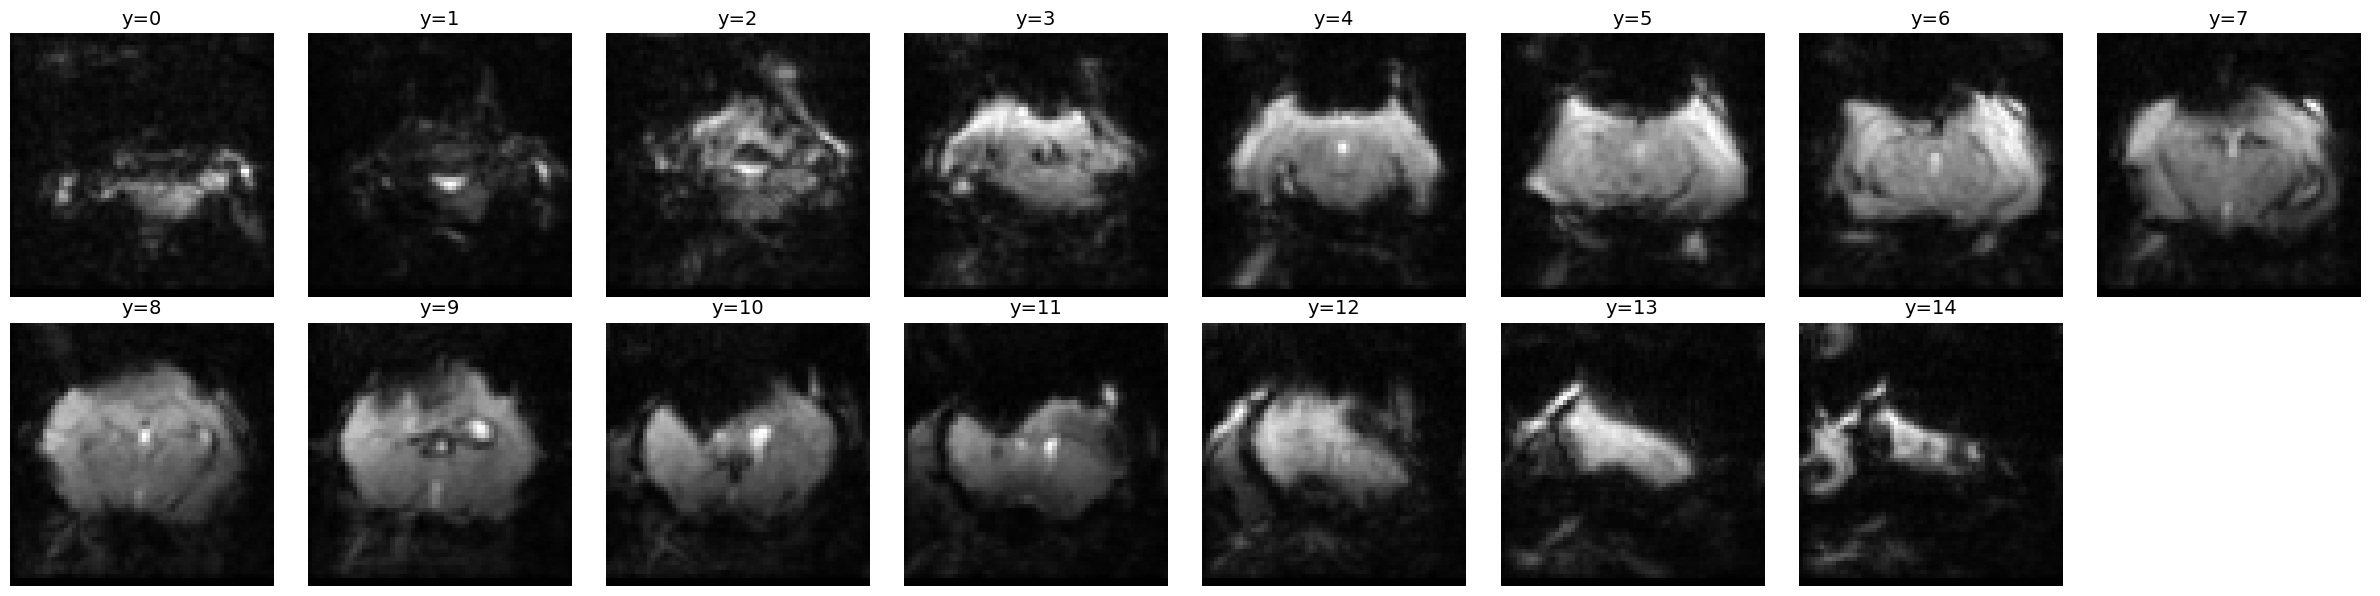

[INFO] Creating motion plots…


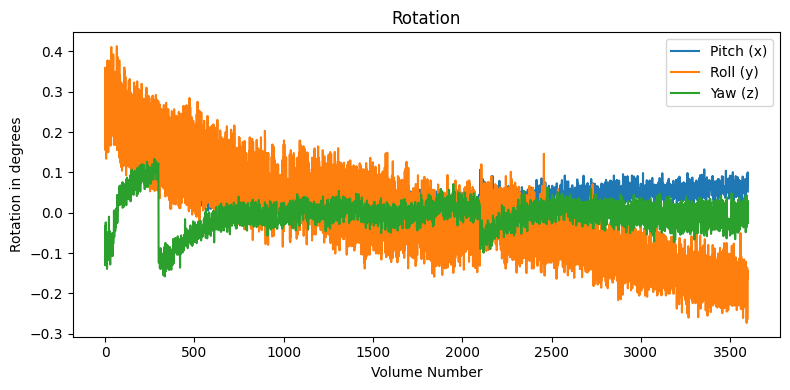

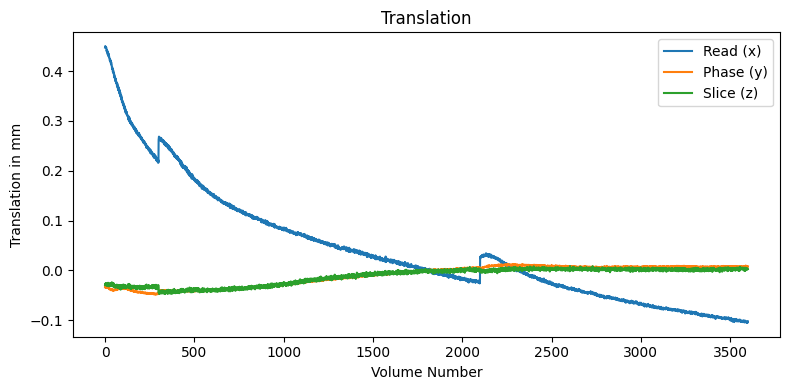

In [10]:
input_name_for_next_step = "func"

if is_step_enabled("motion_correction"):
    print_header("Applying Motion Correction on raw functional data and plotting motion parameters", bcolors.HEADER)

    if os.path.exists("mc_func.nii.gz"):
        print(f"{bcolors.OKGREEN}Motion Corrected functional data exists. Skipping motion correction.{bcolors.ENDC}")
    else:
        motion_correction("middle_vol.nii.gz", f"{input_name_for_next_step}.nii.gz", output_prefix=f"mc_{input_name_for_next_step}")
    
        
    #Display of the motion corrected image and motion corrected graphs
    input_name_for_next_step = f"mc_{input_name_for_next_step}"
    view_images("mc_func.nii.gz", cmap="gray")
    plot_motion_parameters("motion.1D")    
else:
    print_statement("⏭️ Motion Correction not executed", bcolors.NOTIFICATION)


# Move into further subdirectory within Analysed Data Folder

In [11]:
print_statement(f"Analysed Data Path Final: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

mask_file = os.path.join(analysed_func_dir, "mask_mean_mc_func.nii.gz")
mask_file_cannulas = os.path.join(analysed_func_dir, "mask_mean_mc_func_cannulas.nii.gz")

shutil.copyfile(f"../{input_name_for_next_step}.nii.gz", f"{input_name_for_next_step}.nii.gz")

Analysed Data Path Final: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt


'mc_func.nii.gz'

# Selecting Start indices for both: Baseline and Signal

In [13]:
# Opening fsleyes to view the temporally smoothed motion corrected functional data
print_statement("Choose your baseline and signal volumes from the temporally smoothed motion corrected functional data.", bcolors.NOTIFICATION)
subprocess.run(["fsleyes", f"{input_name_for_next_step}.nii.gz"])

scan_ranges = []
boundaries_csv = analysed_func_dir / "scan_boundaries.csv"
if boundaries_csv.exists():
    with open(boundaries_csv) as f:
        scan_ranges = [(int(r["scan"]), int(r["start_volume"]), int(r["end_volume"])) for r in csv.DictReader(f)]
    print_statement("Scan boundaries in the stitched series (keep each window within one scan):", bcolors.NOTIFICATION)
    for scan, start, end in scan_ranges:
        print(f"  Scan {scan}: volumes {start}-{end}")

# ---------- Common styling ----------
input_layout = widgets.Layout(width="280px", flex="0 0 auto")
label_style = {'description_width': '410px'}

# ---------- Widgets ----------
base_start_idx = widgets.IntText(value=300, description="Baseline Start Index:", layout=input_layout, style=label_style)
sig_start_idx = widgets.IntText(value=1800, description="Signal Start Index:", layout=input_layout, style=label_style)

for w in [base_start_idx, sig_start_idx]:
    w.style.description_width = "180px"

# ---------- Container ----------
row = widgets.HBox([base_start_idx, sig_start_idx],
    layout=widgets.Layout(width="40%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e"))

display(row)

Choose your baseline and signal volumes from the temporally smoothed motion corrected functional data.


Exception ignored while finalizing file <_io.TextIOWrapper name=3 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
Exception ignored while finalizing file <_io.TextIOWrapper name=4 mode='r' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=6 mode='r' encoding='UTF-8'>:
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Exception ignored while finalizing file <_io.TextIOWrapper name=5 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwa

Scan boundaries in the stitched series (keep each window within one scan):
  Scan 1: volumes 0-299
  Scan 2: volumes 300-2099
  Scan 3: volumes 2100-3599


/Users/pschmidt/fsl/share/fsl/bin/fsleyes: line 2: 24045 Killed: 9               /Users/pschmidt/fsl/bin/python -I /Users/pschmidt/fsl/bin/fsleyes "$@"


In [14]:
base_start = int(base_start_idx.value)
sig_start  = int(sig_start_idx.value)
base_end   = base_start + int(win_entered.value)
sig_end   = sig_start + int(win_entered.value)

print_statement(f"Your baseline window selected is: {base_start}_to_{base_end}", bcolors.OKGREEN)
print_statement(f"Your signal window selected is: {sig_start}_to_{sig_end}", bcolors.OKGREEN)

for label, w_start, w_end in (("Baseline", base_start, base_end), ("Signal", sig_start, sig_end)):
    if scan_ranges and not any(s <= w_start and w_end <= e for _, s, e in scan_ranges):
        print_statement(f"{label} window {w_start}-{w_end} crosses a scan boundary.", bcolors.FAIL)

Your baseline window selected is: 2100_to_2300
Your signal window selected is: 3100_to_3300


# Apply Spatial Smoothing and Generating Signal Change Map

In [15]:
input_name_for_next_step = "mc_func"

In [16]:

motion_corrected_file = "mc_func.nii.gz"

print(f"{input_name_for_next_step}.nii.gz")

if is_step_enabled("spatial_smoothing"):
    print_header("Applying Spatial Smoothing on motion corrected functional data", bcolors.HEADER)
    spatial_smoothing(f"{input_name_for_next_step}.nii.gz", f"sm_{input_name_for_next_step}.nii.gz", 0.297)
    input_name_for_next_step = f"sm_{input_name_for_next_step}"
else: 
    print_statement("⏭️ Spatial Smoothing not executed, will not get smoothed data in further pipeline", bcolors.NOTIFICATION)
    
compute_mean_range(input_file=f"{input_name_for_next_step}.nii.gz", prefix=f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", start_idx=base_start, end_idx=base_end)
compute_mean_range(input_file=f"{input_name_for_next_step}.nii.gz", prefix=f"mean_signal_image_{sig_start}_to_{sig_end}.nii.gz", start_idx=sig_start, end_idx=sig_end)

signal_change_map(f"mean_signal_image_{sig_start}_to_{sig_end}.nii.gz", f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", f"scm_from_sm_{input_name_for_next_step}.nii.gz") # Creating SCM image
signal_change_map(f"{input_name_for_next_step}.nii.gz", f"mean_baseline_image_{base_start}_to_{base_end}.nii.gz", f"scm_timeseries_from_sm_{input_name_for_next_step}.nii.gz") # Creating Signal Change Time Series


mean_image(motion_corrected_file, "mean_mc_func.nii.gz")
masking_file("mean_mc_func.nii.gz", mask_file_shrunk, "cleaned_shrunk_mean_mc_func.nii.gz")
masking_file("mean_mc_func.nii.gz", mask_file, "cleaned_mean_mc_func.nii.gz")

# Create intensity mask based for the functional image
create_intensity_mask("cleaned_shrunk_mean_mc_func.nii.gz", "mask_thresholded.nii.gz", 15, 80)
final_mask_used = os.path.join(analysis_dir, "mask_thresholded.nii.gz")


if is_step_enabled("masking_file"):
    print_header("Applying Mask on motion corrected functional data", bcolors.HEADER)
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", final_mask_used, f"clean_thresh_scm_from_sm_{input_name_for_next_step}.nii.gz")
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", mask_file_shrunk, f"clean_shrunk_scm_from_sm_{input_name_for_next_step}.nii.gz")
    masking_file(f"scm_from_sm_{input_name_for_next_step}.nii.gz", mask_file, f"cleaned_scm_from_sm_{input_name_for_next_step}.nii.gz")

else:
    print_statement("⏭️ Masking not executed, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)


input_file_for_coreg = analysis_dir / "cleaned_mean_mc_func.nii.gz"
scm_for_coreg = analysis_dir / f"cleaned_scm_from_sm_{input_name_for_next_step}.nii.gz"

mc_func.nii.gz

**************************************************************************************************************************************
                                    Applying Spatial Smoothing on motion corrected functional data                                    
**************************************************************************************************************************************

Smoothing completed successfully.
[INFO] Running: 3dTstat -mean -prefix mean_baseline_image_2100_to_2300.nii.gz sm_mc_func.nii.gz[2100..2300]


++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox
++ Output dataset ./mean_baseline_image_2100_to_2300.nii.gz
++ 3dTstat: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: KR Hammett & RW Cox


[OK] Mean baseline image saved.
[INFO] Running: 3dTstat -mean -prefix mean_signal_image_3100_to_3300.nii.gz sm_mc_func.nii.gz[3100..3300]


++ Output dataset ./mean_signal_image_3100_to_3300.nii.gz


[OK] Mean baseline image saved.
[OK] Percent Signal Change Map saved → scm_from_sm_sm_mc_func.nii.gz
[OK] Percent Signal Change Map saved → scm_timeseries_from_sm_sm_mc_func.nii.gz
[OK] Mean image saved -> mean_mc_func.nii.gz
[OK] Masked file saved → cleaned_shrunk_mean_mc_func.nii.gz
[OK] Masked file saved → cleaned_mean_mc_func.nii.gz
Mask created: mask_thresholded.nii.gz
Thresholds used: 39388.984 – 75267.570

**************************************************************************************************************************************
                                          Applying Mask on motion corrected functional data                                           
**************************************************************************************************************************************

[OK] Masked file saved → clean_thresh_scm_from_sm_sm_mc_func.nii.gz
[OK] Masked file saved → clean_shrunk_scm_from_sm_sm_mc_func.nii.gz
[OK] Masked file saved → cleaned_scm_from

# Converting Structural Data into NIFTI and Processing it

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy

**************************************************************************************************************************************
                                             Converting Bruker to NIFTI: Structural Data                                              
**************************************************************************************************************************************



/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260818_0224_BL6_1367_1-30-1-anatomy-(E30)]
Fixing orientation to LPI
[OK] Bruker → NIFTI workflow completed.
Cleaning the structural image by manually creating mask
Please create a mask for the structural image and save it as mask_struct.nii.gz


wx._core.wxAssertionError: C++ assertion "nIndex < m_nCount" failed at ./include/wx/arrstr.h(227) in Item(): wxArrayString: index out of bounds
The above exception was the direct cause of the following exception:
SystemError: <class 'wx._core.PaintEvent'> returned a result with an exception set
Exception ignored while finalizing file <_io.TextIOWrapper name=4 mode='r' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
Exception ignored while finalizing file <_io.TextIOWrapper name=3 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=6 mode='r' encoding='UTF-8'>:
Exception ignored in sys.unr

[OK] Masked file saved → cleaned_struct.nii.gz


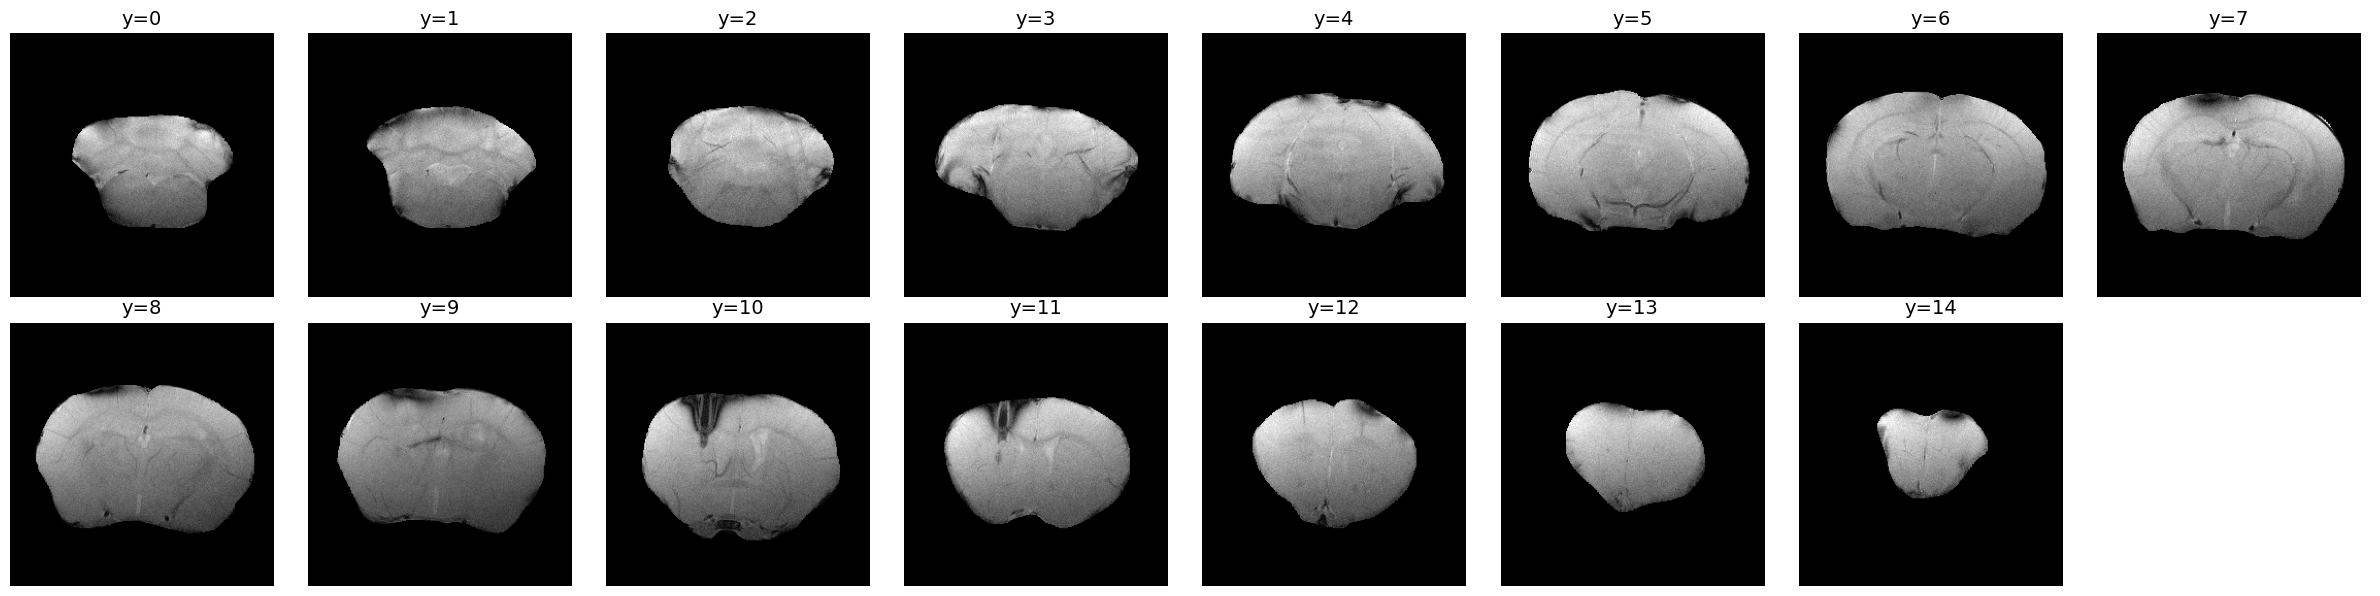

In [17]:
print_statement(f"Analysed Data Path: {analysed_struct_dir}", bcolors.NOTIFICATION)
analysed_struct_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_struct_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI: Structural Data", bcolors.HEADER)

    nifti_file = analysed_struct_dir / "struct.nii.gz"
    if nifti_file.exists():
        print_statement("NIfTI file already exists. Skipping conversion.", bcolors.OKGREEN)
    else:
        bruker_to_nifti(in_path, struct_scan_number, "struct.nii.gz")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)


#Cleaning the structural image by masking it with a manually created mask

if is_step_enabled("masking_file"):
    print_statement("Cleaning the structural image by manually creating mask", bcolors.NOTIFICATION)
    
    if os.path.exists("cleaned_struct.nii.gz"):
        print_statement("Structural Image for Coregistration exists.", bcolors.OKGREEN)
    else:
        print_statement("Please create a mask for the structural image and save it as mask_struct.nii.gz", bcolors.NOTIFICATION)
        subprocess.run(["fsleyes", "struct.nii.gz", os.path.join(analysed_func_dir, "middle_vol.nii.gz")])
        masking_file("struct.nii.gz", "mask_struct.nii.gz", "cleaned_struct.nii.gz")

    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "cleaned_struct.nii.gz")    
    view_images("cleaned_struct.nii.gz", cmap="gray")
    
    #Further shrinking the mask for structural image to get better coregistration results as structural image has high spatial resolution than functional image
    

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)    
    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "struct.nii.gz")    
    view_images("struct.nii.gz", cmap="gray")



In [18]:

print_statement(f"Analysed Data Path Final: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

def coregistration_afni(
    input_file1=None,
    input_file2=None,
    reference_file=None,
    output_file1=None,
    output_file2=None,
    estimate_affine=True,
    apply_affine=True,
    affine_mat="mean_func_struct_aligned.aff12.1D",
):

    results = {}

    if reference_file is None:
        raise ValueError("reference_file must be provided")

    # -------- STEP 1: Estimate transform --------
    if estimate_affine:
        if output_file1 is None:
            raise ValueError("output_file1 must be provided when estimate_affine=True")
        if input_file1 is None:
            raise ValueError("input_file1 must be provided when estimate_affine=True")

        coreg_wo_affine = afni.Allineate()
        coreg_wo_affine.inputs.in_file = input_file1
        coreg_wo_affine.inputs.reference = reference_file

        # Critical change: rigid-body only
        coreg_wo_affine.inputs.warp_type = "shift_rotate"

        # For EPI <-> anat, AFNI generally recommends lpc/lpc+ style costs
        # more than generic affine-style costs
        coreg_wo_affine.inputs.cost = "nmi"

        coreg_wo_affine.inputs.two_pass = True
        coreg_wo_affine.inputs.verbose = True
        coreg_wo_affine.inputs.out_matrix = affine_mat
        coreg_wo_affine.inputs.out_param_file = "params.1D"
        coreg_wo_affine.inputs.out_file = output_file1

        coreg_wo_affine.run()

        print(f"[OK] Rigid transform estimated and saved → {affine_mat}")
        print(f"[OK] Coregistered image (step 1) → {output_file1}")

        results["step1"] = output_file1

    # -------- STEP 2: Apply transform --------
    if apply_affine:
        if output_file2 is None:
            raise ValueError("output_file2 must be provided when apply_affine=True")
        if input_file2 is None:
            raise ValueError("input_file2 must be provided when apply_affine=True")

        coreg_with_affine = afni.Allineate()
        coreg_with_affine.inputs.in_file = input_file2
        coreg_with_affine.inputs.reference = reference_file
        coreg_with_affine.inputs.in_matrix = affine_mat
        coreg_with_affine.inputs.master = reference_file
        coreg_with_affine.inputs.final_interpolation = "linear"
        coreg_with_affine.inputs.verbose = True
        coreg_with_affine.inputs.out_file = output_file2

        coreg_with_affine.run()

        print(f"[OK] Transform applied → {output_file2}")
        results["step2"] = output_file2

    return results

coregistration_afni(input_file_for_coreg, scm_for_coreg, structural_file_for_coregistration, output_file1="mean_func_struct_aligned.nii.gz", output_file2="signal_change_map_coregistered_structural_space.nii.gz", estimate_affine=True, apply_affine=True, affine_mat="mean_func_struct_aligned.aff12.1D") # Estimating affnine and applying it to SCM


create_intensity_mask(structural_file_for_coregistration, "struct_mask_thresholded.nii.gz", 15, 80)
shrink_mask_xz_linewise(in_mask="struct_mask_thresholded.nii.gz", out_mask="struct_mask_thresholded_shrunk.nii.gz", trim_x=2, trim_z=2)  
masking_file("signal_change_map_coregistered_structural_space.nii.gz", "struct_mask_thresholded_shrunk.nii.gz", "cleaned_signal_change_map_coregistered_structural_space.nii.gz")



Analysed Data Path Final: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt
261005-15:19:26,685 nipype.interface INFO:
	 stderr 2026-10-05T15:19:26.684892:++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
261005-15:19:26,686 nipype.interface INFO:
	 stderr 2026-10-05T15:19:26.684892:++ Authored by: Zhark the Registrator
261005-15:19:26,707 nipype.interface INFO:
	 stderr 2026-10-05T15:19:26.707435:++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/cleaned_mean_mc_func.nii.gz
261005-15:19:26,707 nipype.interface INFO:
	 stderr 2026-10-05T15:19:26.707435:++ Base dataset:   /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy/cleaned_struct.nii.gz
261005-15:19:26,708 nipype.interface INFO:
	 stderr 2026-10-

'cleaned_signal_change_map_coregistered_structural_space.nii.gz'

# Stimulation Setup

Locates the stimulation scan (the one with `FMRIYesNo=Yes` in its Bruker `method` file) in the stitched series and derives the epoch timing. The stimulation check itself is run on the mean time course of every atlas region in the atlas section below, so no manually drawn ROIs are needed.

Stimulation: 5 Hz pulses (200 ms interval, 100 µs width, 3 mA), 40 s ON / 20 s OFF per 60 s epoch. The epoch timing is read from the `method` file (`PreBaselineNum`, `StimNum` + `InterStimNum`, `NEpochs`); the ON/OFF split is set below because the `method` file only stores the 60 s period.

Percent signal change is relative to the pre-stimulation baseline at the start of the stimulation scan. A paired t-test across epochs compares the ON window (after the hemodynamic lag) with the rest period right before each onset.


In [22]:
from scipy import stats

STIM_ON_S = 40
STIM_OFF_S = 20
LAG_S = 5   # hemodynamic delay excluded from the start of the ON window
PRE_S = 10  # rest window before each onset used as the comparison

if not scan_ranges:
    raise RuntimeError("scan_boundaries.csv not found, cannot locate the stimulation scan in the stitched series.")

stim_idx = next((i for i, num in enumerate(func_scan_numbers)
                 if re.search(r"##\$FMRIYesNo=Yes", (Path(in_path) / num / "method").read_text())), None)
if stim_idx is None:
    raise ValueError(f"None of the scans {func_scan_numbers} has FMRIYesNo=Yes in its method file.")

stim_num = func_scan_numbers[stim_idx]
p_stim = func_param_extract(Path(in_path) / stim_num, export_env=False)
stim_tr = p_stim["VolTR"]
_, stim_start, stim_end = scan_ranges[stim_idx]
stim_end += 1  # exclusive

n_base_vols = p_stim["Baseline_TRs"]
period_vols = p_stim["StimOn_TRs"] + p_stim["StimOff_TRs"]
if abs(period_vols * stim_tr - (STIM_ON_S + STIM_OFF_S)) > 1e-6:
    print_statement(f"Epoch period in method file ({period_vols * stim_tr:.0f} s) differs from STIM_ON_S + STIM_OFF_S.", bcolors.FAIL)

on_vols = int(round(STIM_ON_S / stim_tr))
lag_vols = int(round(LAG_S / stim_tr))
pre_vols = int(round(PRE_S / stim_tr))
onsets = [stim_start + n_base_vols + k * period_vols for k in range(p_stim["NoOfEpochs"])]
onsets = [o for o in onsets if o + period_vols <= stim_end]

print_statement(f"Stimulation scan {stim_num} (volumes {stim_start}-{stim_end - 1}): {len(onsets)} epochs, "
                f"first onset at volume {onsets[0]}, period {period_vols * stim_tr:.0f} s", bcolors.NOTIFICATION)


Stimulation scan 31 (volumes 300-2099): 27 epochs, first onset at volume 480, period 60 s


# Atlas Coregistration and Stimulation Response per Brain Region

Select the species in the widget cell below; it fills in the matching atlas:
- **Rat:** SIGMA in vivo template, rigid registration.
- **Mouse:** DSURQE (MICe) template. It is an ex vivo, whole-head average, so it is brain-masked, downsampled to 0.1 mm for registration, and registered with a scaling term and `nmi` cost. Any other mouse template/label pair (e.g. Allen CCFv3) can be entered instead.

Follows `roi_atlas_analysis.py`: the structural scan is registered to the functional mean (struct2func, rigid) and to the atlas template (struct2atlas), and the two matrices are composed into one functional → atlas matrix. The multi-label atlas is resampled once onto the functional grid with nearest-neighbour interpolation, so the functional data itself is never interpolated. Outputs go to `roi_atlas_<species>/`.

Then the mean time course of every atlas region (inside the brain mask) is extracted and the stimulation check (paired t-test, ON window vs. preceding rest) is run on each region, with Benjamini-Hochberg FDR correction across regions. Requires the stimulation setup cell above to have been run. This replaces manually drawn ROIs. Outputs:
- `atlas_roi_stim_response.csv`: every region with ON/rest signal change, t, p and FDR-corrected q; `atlas_roi_responders.csv` lists only the regions with a significant positive response.
- `time_courses/time_course_roi_<id>_<name>.txt`: mean time course of every region.
- `stim_check_plots/`: one figure per region (full scan with stimulation periods and the epoch average ± SEM); the responders are also in `stim_check_plots/responders/`.
- The somatosensory (S1) regions are printed separately as a check that the stimulation worked.

Optional label names CSV: either columns `id,name`, or the DSURQE / SIGMA structure lists with separate left and right label columns (regions then get an `_L` / `_R` suffix). Without it, regions are named `label_<id>`.


In [23]:
ATLAS_ROOT = f"{FMRI_ROOT}/atlas"
SIGMA_DIR = (f"{ATLAS_ROOT}/SIGMA_rat_atlas/sigma_wistar_rat_brain_templatesandatlases_version1-2-1_2022-08-26/"
             "SIGMA_Wistar_Rat_Brain_TemplatesAndAtlases_Version1.2.1")
SIGMA_ATLAS_DIR = f"{SIGMA_DIR}/SIGMA_Rat_Brain_Atlases/SIGMA_Anatomical_Atlas/InVivo_Atlas"

# Rat: SIGMA in vivo. Mouse: DSURQE (40 µm, ex vivo T2w).
SPECIES_ATLAS = {
    "rat": {
        "template": f"{SIGMA_DIR}/SIGMA_Rat_Anatomical_Imaging/SIGMA_Rat_Anatomical_InVivo_Template/SIGMA_InVivo_Brain_Template_Masked.nii",
        "labels": f"{SIGMA_ATLAS_DIR}/SIGMA_InVivo_Anatomical_Brain_Atlas.nii",
        "mask": "", "names": f"{SIGMA_ATLAS_DIR}/SIGMA_InVivo_Anatomical_Brain_Atlas_ListOfStructures.csv",
        "warp": "shift_rotate", "cost": "lpa+ZZ", "reg_voxel_mm": None,
    },
    "mouse": {
        "template": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_average.nii",
        "labels": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii",
        "mask": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/DSURQE_40micron_mask.nii",
        "names": f"{ATLAS_ROOT}/DSURQE_mouse_atlas/dsurqe_labels.csv",
        # Scaling absorbs the size difference between in vivo brains and the ex vivo template
        "warp": "shift_rotate_scale", "cost": "nmi", "reg_voxel_mm": 0.1,
    },
}

atlas_layout = widgets.Layout(width="700px")
atlas_style = {"description_width": "160px"}
species_dropdown = widgets.Dropdown(options=list(SPECIES_ATLAS), value="rat", description="Species:", layout=widgets.Layout(width="280px"), style=atlas_style)
atlas_template_entered = widgets.Text(description="Atlas template:", layout=atlas_layout, style=atlas_style)
atlas_labels_entered = widgets.Text(description="Atlas labels:", layout=atlas_layout, style=atlas_style)
atlas_mask_entered = widgets.Text(placeholder="optional, restricts the template to the brain", description="Template brain mask:", layout=atlas_layout, style=atlas_style)
atlas_names_entered = widgets.Text(placeholder="optional CSV (id,name or left/right label columns)", description="Label names CSV:", layout=atlas_layout, style=atlas_style)


def fill_atlas_defaults(change=None):
    cfg = SPECIES_ATLAS[species_dropdown.value]
    atlas_template_entered.value = cfg["template"]
    atlas_labels_entered.value = cfg["labels"]
    atlas_mask_entered.value = cfg["mask"]
    atlas_names_entered.value = cfg["names"]


species_dropdown.observe(fill_atlas_defaults, names="value")
fill_atlas_defaults()

display(widgets.VBox([species_dropdown, atlas_template_entered, atlas_labels_entered, atlas_mask_entered, atlas_names_entered],
    layout=widgets.Layout(padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")))


In [24]:
species = species_dropdown.value
species_cfg = SPECIES_ATLAS[species]
atlas_template = Path(atlas_template_entered.value.strip()).resolve()
atlas_labels = Path(atlas_labels_entered.value.strip()).resolve()
atlas_mask_text = atlas_mask_entered.value.strip()
for f in (atlas_template, atlas_labels) + ((Path(atlas_mask_text),) if atlas_mask_text else ()):
    if not f.is_file():
        raise FileNotFoundError(f"{f} (atlas files for {species} not found; check the paths above)")

atlas_dir = analysis_dir / f"roi_atlas_{species}"
atlas_dir.mkdir(exist_ok=True)
func_reference = analysis_dir / "mean_mc_func.nii.gz"
struct_for_atlas = Path(structural_file_for_coregistration)

# +xz suits a coronal slab with limited A-P coverage
STRUCT2FUNC_COST, STRUCT2FUNC_CMASS = "nmi", None
STRUCT2ATLAS_COST, STRUCT2ATLAS_CMASS = species_cfg["cost"], "+xz"


def run_afni(cmd, capture=False):
    cmd = [str(c) for c in cmd]
    print("[COMMAND]", " ".join(cmd))
    return subprocess.run(cmd, check=True, text=True, capture_output=capture)


def prepare_registration_template():
    """Brain-mask and/or downsample the template so registration is robust and fast."""
    template = atlas_template
    if atlas_mask_text:
        masked = atlas_dir / "template_masked.nii.gz"
        if not masked.exists():
            run_afni(["3dcalc", "-a", template, "-b", atlas_mask_text, "-expr", "a*step(b)", "-prefix", masked])
        template = masked
    if species_cfg["reg_voxel_mm"]:
        vox = species_cfg["reg_voxel_mm"]
        coarse = atlas_dir / f"template_registration_{vox}mm.nii.gz"
        if not coarse.exists():
            run_afni(["3dresample", "-dxyz", vox, vox, vox, "-rmode", "Cu", "-input", template, "-prefix", coarse])
        template = coarse
    return template


def register(source, base, prefix, cost, cmass, warp):
    matrix = atlas_dir / f"{prefix}.aff12.1D"
    aligned = atlas_dir / f"{prefix}_aligned.nii.gz"
    if matrix.exists() and aligned.exists():
        print_statement(f"{prefix} registration already exists. Skipping.", bcolors.OKGREEN)
        return matrix
    cmd = ["3dAllineate", "-source", source, "-base", base, "-prefix", aligned, "-1Dmatrix_save", matrix,
           "-1Dparam_save", atlas_dir / f"{prefix}_params.1D", "-warp", warp, "-cost", cost,
           "-source_automask+2", "-twopass", "-twobest", "MAX", "-float", "-verb", "-overwrite"]
    if cmass:
        cmd.append(f"-cmass{cmass}")
    run_afni(cmd)
    return matrix


def aff12_to_matvec(matrix, out):
    vals = [float(v) for line in Path(matrix).read_text().splitlines()
            if line.strip() and not line.lstrip().startswith("#") for v in line.split()]
    if len(vals) != 12:
        raise ValueError(f"Expected 12 values in {matrix}, found {len(vals)}.")
    Path(out).write_text("\n".join(" ".join(f"{v:.12g}" for v in vals[i:i + 4]) for i in (0, 4, 8)) + "\n")
    return out


print_header(f"Registering structural to functional and to the {species} atlas", bcolors.HEADER)
struct2func = register(struct_for_atlas, func_reference, "struct2func", STRUCT2FUNC_COST, STRUCT2FUNC_CMASS, "shift_rotate")
struct2atlas = register(struct_for_atlas, prepare_registration_template(), "struct2atlas", STRUCT2ATLAS_COST, STRUCT2ATLAS_CMASS, species_cfg["warp"])

# 3dAllineate matrices are base -> source; functional -> atlas = inverse(struct2atlas) after struct2func
composite = atlas_dir / "func_to_atlas_for_roi_apply.aff12.1D"
res = run_afni(["cat_matvec", "-ONELINE",
                aff12_to_matvec(struct2func, atlas_dir / "struct2func.matvec"),
                aff12_to_matvec(struct2atlas, atlas_dir / "struct2atlas.matvec"), "-I"], capture=True)
composite.write_text(res.stdout.strip() + "\n")

# Labels stay at full resolution; the matrix is in physical coordinates so the downsampled template doesn't matter here
labels_funcspace = atlas_dir / "atlas_labels_funcspace.nii.gz"
run_afni(["3dAllineate", "-source", atlas_labels, "-master", func_reference, "-1Dmatrix_apply", composite,
          "-final", "NN", "-prefix", labels_funcspace, "-overwrite"])
print_statement(f"[OK] Atlas labels in functional space: {labels_funcspace}", bcolors.OKGREEN)

# Check the registration visually before trusting the regions
subprocess.run(["fsleyes", str(func_reference), str(labels_funcspace), "-cm", "random", "-a", "40"])



**************************************************************************************************************************************
                                     Registering structural to functional and to the mouse atlas                                      
**************************************************************************************************************************************

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy/cleaned_struct.nii.gz -base /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/mean_mc_func.nii.gz -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/struct2func_aligned.nii.gz -1Dmatrix_save /Volumes/pschmidt/fmri_analysis/AnalysedDa

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy/cleaned_struct.nii.gz
++ Base dataset:   /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/mean_mc_func.nii.gz
++ Loading datasets into memory
++ 320346 voxels in -source_automask+2
++ Zero-pad: xbot=8 xtop=8
++ Zero-pad: ybot=8 ytop=8
++ Zero-pad: zbot=8 ztop=8
++ Computing -autobox
 + Weightize: xfade=7 yfade=4 zfade=7
 + Weightize: (unblurred) top clip=79491.1
 + Weightize: (blurred) bot clip=2570.56
 + Weightize: 81279 voxels survive clip
 + Weightize: 81233 voxels survive clusterize
 + Weightize: binarizing
 + Weightize: box=1..77 X 1..29 X 1..77 = 171941 voxels
++ -autobox net CPU time = 0.0 s
++ 172326 voxels [86.9%] in weight mask
++ Number of points for ma

[COMMAND] 3dcalc -a /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_average.nii -b /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_mask.nii -expr a*step(b) -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/template_masked.nii.gz


*+ WARNING: dataset 'b'=/Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_mask.nii grid mismatch with /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_average.nii
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/template_masked.nii.gz


[COMMAND] 3dresample -dxyz 0.1 0.1 0.1 -rmode Cu -input /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/template_masked.nii.gz -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/template_registration_0.1mm.nii.gz
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/30anatomy/cleaned_struct.nii.gz -base /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/template_registration_0.1mm.nii.gz -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/st

...

[COMMAND] cat_matvec -ONELINE /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/struct2func.matvec /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/struct2atlas.matvec -I
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii -master /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/mean_mc_func.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/func_to_atlas_for_roi_apply.aff12.1D -final NN -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electr

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    4.032    6.125    3.082
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/atlas_labels_funcspace.nii.gz
++ 3dAllineate: total CPU time = 0.5 sec  Elapsed = 2.1
++ ###########################################################


[OK] Atlas labels in functional space: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/atlas_labels_funcspace.nii.gz


Exception ignored while finalizing file <_io.TextIOWrapper name=4 mode='r' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
Exception ignored while finalizing file <_io.TextIOWrapper name=3 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor
Exception ignored while finalizing file <_io.TextIOWrapper name=6 mode='r' encoding='UTF-8'>:
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Exception ignored while finalizing file <_io.TextIOWrapper name=5 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwa

CompletedProcess(args=['fsleyes', '/Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/mean_mc_func.nii.gz', '/Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260818_0224_BL6_1367/stitched_36-31-40_functionalEPI/2026_10_05_150456_pschmidt/roi_atlas_mouse/atlas_labels_funcspace.nii.gz', '-cm', 'random', '-a', '40'], returncode=0)

In [ ]:
from statsmodels.stats.multitest import multipletests

MIN_VOXELS = 5
FDR_ALPHA = 0.05
N_PLOT = 12
SAVE_ALL_REGION_PLOTS = True  # one stim-check figure per region in stim_check_plots/ (responders always saved)
S1_PATTERN = r"somatosens|\bS1"  # regions printed as the stimulation sanity check

labels_img = nib.load(str(labels_funcspace))
labels = np.rint(labels_img.get_fdata()).astype(int)
brain = nib.load(mask_file).get_fdata() > 0
if brain.shape != labels.shape:
    raise ValueError(f"Brain mask {brain.shape} and atlas labels {labels.shape} are on different grids.")
labels[~brain] = 0

func_4d = nib.load("mc_func.nii.gz").get_fdata(dtype=np.float32)


def load_label_names(csv_path):
    """Accepts an id,name CSV or the DSURQE/SIGMA layouts with separate left and right label columns."""
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    if "id" in cols and "name" in cols:
        return {int(i): str(n) for i, n in zip(df[cols["id"]], df[cols["name"]])}
    left = next(c for k, c in cols.items() if "left" in k and "label" in k)
    right = next(c for k, c in cols.items() if "right" in k and "label" in k)
    name_col = next(c for k, c in cols.items() if k in ("structure", "region of interest"))
    names = {}
    for _, row in df.iterrows():
        for col, side in ((left, "L"), (right, "R")):
            if pd.notna(row[col]):
                names[int(row[col])] = f"{row[name_col]}_{side}"
    return names


label_names = load_label_names(atlas_names_entered.value.strip()) if atlas_names_entered.value.strip() else {}


def stim_response(ts):
    base = ts[stim_start:stim_start + n_base_vols].mean()
    psc = (ts - base) / base * 100
    epochs = np.array([psc[o - pre_vols:o + period_vols] for o in onsets])
    on = epochs[:, pre_vols + lag_vols:pre_vols + on_vols].mean(axis=1)
    rest = epochs[:, :pre_vols].mean(axis=1)
    t_stat, p_val = stats.ttest_rel(on, rest)
    return epochs, on.mean(), rest.mean(), t_stat, p_val


def safe_name(text):
    return re.sub(r"[^\w.\-]+", "_", str(text)).strip("_")


tc_dir = atlas_dir / "time_courses"
tc_dir.mkdir(exist_ok=True)
plot_dir = atlas_dir / "stim_check_plots"
plot_dir.mkdir(exist_ok=True)
(plot_dir / "responders").mkdir(exist_ok=True)

rows, region_ts, region_epochs = [], {}, {}
for lid in np.unique(labels[labels > 0]):
    sel = labels == lid
    n_vox = int(sel.sum())
    if n_vox < MIN_VOXELS:
        continue
    ts = func_4d[sel].mean(axis=0)
    if ts[stim_start:stim_start + n_base_vols].mean() <= 0:
        continue
    epochs, on_psc, rest_psc, t_stat, p_val = stim_response(ts)
    np.savetxt(tc_dir / f"time_course_roi_{lid}_{safe_name(label_names.get(int(lid), f'label_{lid}'))}.txt", ts)
    region_ts[lid] = ts
    region_epochs[lid] = epochs
    rows.append({"label_id": int(lid), "name": label_names.get(int(lid), f"label_{lid}"), "n_voxels": n_vox,
                 "on_psc": on_psc, "rest_psc": rest_psc, "diff_psc": on_psc - rest_psc, "t": t_stat, "p": p_val})

results = pd.DataFrame(rows)
valid = results["p"].notna()
results.loc[valid, "q_fdr"] = multipletests(results.loc[valid, "p"], alpha=FDR_ALPHA, method="fdr_bh")[1]
results = results.sort_values("p").reset_index(drop=True)
results["responder"] = (results["q_fdr"] < FDR_ALPHA) & (results["diff_psc"] > 0)

results.to_csv(atlas_dir / "atlas_roi_stim_response.csv", index=False)
results[results["responder"]].to_csv(atlas_dir / "atlas_roi_responders.csv", index=False)
pd.DataFrame({results.loc[results.label_id == lid, "name"].iloc[0]: ts for lid, ts in region_ts.items()}).to_csv(
    atlas_dir / "atlas_roi_timeseries_all.csv", index_label="timepoint")

print_statement(f"{len(results)} regions analysed, {int(results['responder'].sum())} with significant positive response (FDR q < {FDR_ALPHA})", bcolors.OKGREEN)
print(results.head(20).to_string(index=False))

s1 = results[results["name"].str.contains(S1_PATTERN, case=False, regex=True)]
print_statement("Somatosensory (S1) regions:" if len(s1) else "No region name matches S1_PATTERN (provide a label names CSV).", bcolors.NOTIFICATION)
if len(s1):
    print(s1.to_string(index=False))

# Map of the ON - rest signal change in regions that respond
response_map = np.zeros(labels.shape, dtype=np.float32)
for r in results[results["responder"]].itertuples():
    response_map[labels == r.label_id] = r.diff_psc
nib.save(nib.Nifti1Image(response_map, labels_img.affine, labels_img.header), str(atlas_dir / "atlas_roi_stim_response_map.nii.gz"))

# Epoch averages of the strongest regions
t_epoch = np.arange(-pre_vols, period_vols) * stim_tr
top = results.head(N_PLOT)
fig, axes = plt.subplots(int(np.ceil(len(top) / 4)), 4, figsize=(18, 3.5 * int(np.ceil(len(top) / 4))), squeeze=False)
for ax, r in zip(axes.flat, top.itertuples()):
    ep = region_epochs[r.label_id]
    m = ep.mean(axis=0)
    sem = ep.std(axis=0, ddof=1) / np.sqrt(len(ep))
    ax.plot(t_epoch, m)
    ax.fill_between(t_epoch, m - sem, m + sem, alpha=0.3)
    ax.axvspan(0, STIM_ON_S, color="orange", alpha=0.3)
    ax.set_title(f"{r.name}\nΔ={r.diff_psc:.2f}%, q={r.q_fdr:.3g}", fontsize=9)
    ax.set_xlabel("Time from onset (s)")
    ax.set_ylabel("Signal change (%)")
for ax in list(axes.flat)[len(top):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(atlas_dir / "atlas_roi_stim_response_top_regions.svg", dpi=300)
plt.show()


def save_region_plot(r):
    ts, ep = region_ts[r.label_id], region_epochs[r.label_id]
    base = ts[stim_start:stim_start + n_base_vols].mean()
    psc = (ts - base) / base * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot((np.arange(stim_start, stim_end) - stim_start) * stim_tr, psc[stim_start:stim_end], lw=0.8)
    for o in onsets:
        ax1.axvspan((o - stim_start) * stim_tr, (o - stim_start + on_vols) * stim_tr, color="orange", alpha=0.3)
    ax1.set_xlabel("Time in stimulation scan (s)")
    ax1.set_ylabel("Signal change (%)")
    ax1.set_title(f"{r.name} ({r.n_voxels} voxels): stimulation scan {stim_num} (orange = stimulation ON)")
    m = ep.mean(axis=0)
    sem = ep.std(axis=0, ddof=1) / np.sqrt(len(ep))
    ax2.plot(t_epoch, m)
    ax2.fill_between(t_epoch, m - sem, m + sem, alpha=0.3)
    ax2.axvspan(0, STIM_ON_S, color="orange", alpha=0.3)
    ax2.axvline(0, color="k", lw=0.5)
    ax2.set_xlabel("Time from stimulation onset (s)")
    ax2.set_ylabel("Signal change (%)")
    ax2.set_title(f"Epoch average ± SEM (n={len(ep)}), ON {r.on_psc:.2f}% vs rest {r.rest_psc:.2f}%, "
                  f"t={r.t:.2f}, p={r.p:.3g}, q={r.q_fdr:.3g}")
    fig.tight_layout()
    fname = f"stim_check_{r.label_id}_{safe_name(r.name)}.svg"
    if SAVE_ALL_REGION_PLOTS:
        fig.savefig(plot_dir / fname, dpi=300)
    if r.responder:
        fig.savefig(plot_dir / "responders" / fname, dpi=300)
    plt.close(fig)


for r in results.itertuples():
    if SAVE_ALL_REGION_PLOTS or r.responder:
        save_region_plot(r)
print_statement(f"Stim-check figures saved in {plot_dir} ({int(results['responder'].sum())} responders in {plot_dir / 'responders'})", bcolors.OKGREEN)
print_statement(f"Region time courses saved in {tc_dir}", bcolors.OKGREEN)


# Voxelwise Stimulation Maps in Atlas Space (for group analysis)

The region analysis above stays in native space, so the functional time series are never interpolated. For voxelwise group statistics, the maps are computed in native space and then moved to atlas space with the inverse of the functional → atlas matrix estimated above (struct2func and struct2atlas), in a single resampling step:
- `stim_diff_psc`: mean ON − rest signal change (%) per voxel.
- `stim_tstat`: paired t of ON vs. rest across epochs per voxel (n epochs − 1 degrees of freedom).
- `mean_func` and `brain_mask`, for overlays and for restricting the group statistics to the brain.

Outputs go to `roi_atlas_<species>/atlas_space/` on the registration template grid, which is the same for every animal of the species. Region-wise group comparisons can use `atlas_roi_stim_response.csv` directly, since the atlas labels already define the same regions in every animal.

In [ ]:
# Voxelwise ON - rest maps in native space (same definition as the region analysis: ON window after the lag vs. the rest right before each onset)
base_img = func_4d[..., stim_start:stim_start + n_base_vols].mean(axis=-1)
valid_vox = brain & (base_img > 0)
diffs = []
for o in onsets:
    on = func_4d[..., o + lag_vols:o + on_vols].mean(axis=-1)
    rest = func_4d[..., o - pre_vols:o].mean(axis=-1)
    diffs.append(np.where(valid_vox, (on - rest) / np.where(valid_vox, base_img, 1) * 100, 0))
diffs = np.stack(diffs)
diff_map = diffs.mean(axis=0)
sd = diffs.std(axis=0, ddof=1)
t_map = np.where(sd > 0, diff_map / (sd / np.sqrt(len(onsets)) + (sd == 0)), 0)
t_map[~valid_vox] = 0

native_maps = atlas_dir / "native_maps"
native_maps.mkdir(exist_ok=True)
mask_img = nib.load(mask_file)
for name, data in (("stim_diff_psc", diff_map), ("stim_tstat", t_map)):
    nib.save(nib.Nifti1Image(data.astype(np.float32), labels_img.affine, labels_img.header), str(native_maps / f"{name}.nii.gz"))

# Native -> atlas: inverse of the functional -> atlas matrix, resampled once onto the registration template grid
atlas_space = atlas_dir / "atlas_space"
atlas_space.mkdir(exist_ok=True)
atlas_grid = prepare_registration_template()
native_to_atlas = atlas_dir / "native_to_atlas.aff12.1D"
res = run_afni(["cat_matvec", "-ONELINE", composite, "-I"], capture=True)
native_to_atlas.write_text(res.stdout.strip() + "\n")

for name, source, interp in (("stim_diff_psc", native_maps / "stim_diff_psc.nii.gz", "linear"),
                             ("stim_tstat", native_maps / "stim_tstat.nii.gz", "linear"),
                             ("mean_func", func_reference, "linear"),
                             ("brain_mask", mask_file, "NN")):
    run_afni(["3dAllineate", "-source", source, "-master", atlas_grid, "-1Dmatrix_apply", native_to_atlas,
              "-final", interp, "-prefix", atlas_space / f"{name}_atlasspace.nii.gz", "-overwrite"])
print_statement(f"[OK] Maps in atlas space: {atlas_space}", bcolors.OKGREEN)

# Check the alignment of the warped maps on the template
subprocess.run(["fsleyes", str(atlas_grid), str(atlas_space / "stim_tstat_atlasspace.nii.gz"), "-cm", "hot", "-dr", "2", "6"])
